# От Score товара к выбору итоговой ассортиментной матрицы

Продолжение [`../Кластеризация точек продаж`](../Кластеризация%20точек%20продаж): там точки сети разбиты на
сегменты, здесь для каждого сегмента строится и выбирается конкретная товарная матрица.

Шаги:

1. посчитать **Score** каждого товара и вес его **юнита** - группы взаимозаменяемых товаров - в сегменте;
2. построить **кандидатов на матрицу** по шкале строгости отбора и выбрать вариант, сравнив каждого с
   действующей матрицей по деньгам: остатки по нормативу запаса, выручка, прибыль;
3. **проверить на отложенных неделях**, что выбранная матрица действительно лучше, и сравнить автосегменты с
   другими способами разбить сеть на группы.

**Про данные.** Расчёт идёт на синтетических данных из общей базы [`../synthetic_data`](../synthetic_data):
справочник лекарств - из открытого реестра ЖНВЛП, продажи и действующая матрица сгенерированы, сегменты точек -
результат ноутбука кластеризации. Цифры не отражают реальный бизнес.

## Импорт библиотек и параметры

In [1]:
import os
import re
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import expon

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

# Те же бизнес-фильтры чеков, что в кластеризации
EXCLUDED_SALE_TYPES = ('Опт', 'Маркетплейс')
MIN_SHELF_LIFE_MONTHS = 6

# Строгость экспоненциального отбора: кривая строится по 10 значениям λ от почти «всё продаваемое» до «только
# лидеры» (чем больше λ, тем строже отбор), а точки пересечения с нулём прибыли и нулём остатков считаются точно -
# λ подбирается делением отрезка пополам.
LAMBDA_GRID = list(dict.fromkeys(float(f'{x:.2g}') for x in np.geomspace(0.01, 2, 10)))
SOLVE_ITERS = 12   # шагов деления отрезка при поиске нулевой точки
LAMBDAS_SHOW = [0.05, 0.2, 1.0]   # для графика формы порога

# Защищённые позиции входят в матрицу независимо от Score: минимальный ассортимент и собственная марка
PROTECT_MIN_ASSORTMENT = True
PROTECT_OWN_BRAND = True

# Доля продаж исключённого товара, которая переходит на оставшиеся товары того же юнита (покупатель берёт аналог)
SUBSTITUTION_RATE = 0.5

# Норматив запаса товара матрицы в аптеке (в штуках):
#   средний запас = max(выкладка, страховой запас + половина объёма поставки),
#   страховой запас = z * sqrt(спрос в день * (срок поставки + интервал заказа)) - спрос случайный (Пуассон),
#   объём поставки = спрос в день * интервал заказа.
DISPLAY_UNITS = 2        # минимум на полке, даже если товар почти не продаётся
LEAD_DAYS = 2            # срок поставки, дней
REVIEW_DAYS = 7          # заказ раз в неделю
SERVICE_Z = 1.65         # уровень сервиса 95%

# Стоимость денег в остатках - для одного итогового числа «прибыль минус стоимость запаса»
CAPITAL_COST_YEAR = 0.20

# Юнит - группа взаимозаменяемых товаров. Для лекарств взаимозаменяемы только товары с одним действующим
# веществом, одной формой и путём введения, одной дозировкой и сопоставимым объёмом пачки:
# - форма уточняется по полному названию: капли глазные и назальные, таблетки обычные и пролонгированные,
#   ингалятор и раствор для небулайзера - разные юниты (правила ниже, первое совпадение);
# - дозировка: 200 и 400 мг ибупрофена, детская и взрослая - разные юниты;
# - фасовка (число доз в упаковке): пачка на 10 и на 100 таблеток - разные юниты. Категории фасовки - те же, что в
#   ценовом анализе кластеризации; нештучные формы по фасовке не делятся.
UNIT_FORM_RULES = {
    'таблетки': [(r'вагинальн', 'таблетки вагинальные'),
                 (r'подъязычн|защечн|рассасыв', 'таблетки подъязычные и для рассасывания'),
                 (r'шипуч|диспергир', 'таблетки растворимые'),
                 (r'пролонг|модифицир|контролир', 'таблетки пролонгированного действия'),
                 (r'кишечнорастворим', 'таблетки кишечнорастворимые')],
    'капсулы': [(r'ингаляц', 'капсулы с порошком для ингаляций'),
                (r'пролонг|модифицир', 'капсулы пролонгированного действия'),
                (r'кишечнорастворим', 'капсулы кишечнорастворимые')],
    'суппозитории': [(r'вагинальн', 'суппозитории вагинальные'), (r'', 'суппозитории ректальные')],
    'капли': [(r'глазн', 'капли глазные'), (r'назальн', 'капли назальные'), (r'ушн', 'капли ушные'),
              (r'внутрь', 'капли для приема внутрь')],
    'мазь, крем, гель': [(r'глазн', 'мазь глазная'), (r'назальн', 'гель назальный'),
                         (r'пластыр', 'пластырь трансдермальный'), (r'', 'мазь, крем, гель наружные')],
    'спрей и ингаляции': [(r'назальн', 'спрей назальный'), (r'подъязычн', 'спрей подъязычный'),
                          (r'аэрозоль для ингаляций|порошок для ингаляций', 'ингалятор'),
                          (r'для ингаляций', 'раствор для небулайзера'), (r'', 'спрей наружный')],
    'порошок': [(r'пролонг', 'гранулы пролонгированного действия'), (r'', 'порошок для приема внутрь')],
    'жидкость внутрь': [(r'', 'сироп, суспензия, раствор внутрь')],
}
PACK_BINS = [(1, '1'), (4, '2-4'), (8, '5-8'), (12, '9-12'), (20, '13-20'), (30, '21-30'),
             (50, '31-50'), (100, '51-100'), (np.inf, '100+')]

# Эксперимент: сколько случайных разбиений сети усреднять
N_RANDOM = 5
SEED = 2026

## Данные

Период чеков делится пополам: **первая половина - обучение** (по ней кластеризация построила сегменты, а здесь
считаются Score, варианты матриц и выбор варианта), **вторая - отложенная проверка**: на ней выбранные матрицы
оцениваются по продажам, которых расчёт не видел.

In [3]:
con = duckdb.connect(DB_PATH)


def query(sql: str, params=None) -> pd.DataFrame:
    return con.execute(sql, params or []).df()


tables = set(query("SELECT table_schema || '.' || table_name AS t FROM information_schema.tables").t)
assert 'results.store_segments' in tables, 'Сначала выполните ноутбук кластеризации точек: он пишет сегменты в базу'

period = query("SELECT MIN(Date) AS d0, MAX(Date) AS d1 FROM pharmacy.cheques").iloc[0]
DATE_FROM, DATA_END = pd.Timestamp(period.d0), pd.Timestamp(period.d1)
TRAIN_DAYS = ((DATA_END - DATE_FROM).days + 1) // 2
TRAIN_END = DATE_FROM + pd.Timedelta(days=TRAIN_DAYS - 1)
TEST_DAYS = (DATA_END - TRAIN_END).days
print(f'Обучение: {DATE_FROM:%d.%m.%Y} - {TRAIN_END:%d.%m.%Y} ({TRAIN_DAYS} дн.), '
      f'проверка: {TRAIN_END + pd.Timedelta(days=1):%d.%m.%Y} - {DATA_END:%d.%m.%Y} ({TEST_DAYS} дн.)')

stores = query("""
    SELECT s.TradePointId, s.segment, s.price_level, st.CurrentCategory, a.archetype
    FROM results.store_segments s
    JOIN pharmacy.stores st USING (TradePointId)
    JOIN pharmacy.store_archetypes a USING (TradePointId)
""").set_index('TradePointId')
print(f'{len(stores)} точек в {stores.segment.nunique()} сегментах')

Обучение: 02.03.2026 - 29.03.2026 (28 дн.), проверка: 30.03.2026 - 26.04.2026 (28 дн.)
234 точек в 13 сегментах


In [4]:
# продажи «точка × товар» отдельно за обучение и за проверку
sp = query(f"""
    SELECT c.TradePointId, c.apCode,
           CASE WHEN c.Date <= ? THEN 'train' ELSE 'test' END AS period,
           SUM(c.Amount)                  AS units,
           SUM(c.Sum_Fact)                AS revenue,
           SUM(c.Sum_Fact - c.Sum_Purch)  AS profit
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
      AND c.TradePointId IN (SELECT TradePointId FROM results.store_segments)
    GROUP BY 1, 2, 3
""", [TRAIN_END])
train = sp[sp.period == 'train'].drop(columns='period')
test = sp[sp.period == 'test'].drop(columns='period')

products = query("""
    SELECT p.apCode, p.name, p.mnn, p.form_group, p.form_name, p.dosage, p.subcategory, p.doses_in_pack, p.is_min_assortment,
           p.is_own_brand, p.base_price
    FROM pharmacy.products p
    WHERE p.product_class <> 'Нетоварные позиции'
""")


def unit_form(form_group: str, form_name: str) -> str:
    """Лекарственная форма юнита: группа формы, уточнённая путём введения и типом высвобождения."""
    for pattern, name in UNIT_FORM_RULES.get(form_group, []):
        if re.search(pattern, form_name):
            return name
    return form_group


# юнит: для лекарств - МНН + форма юнита + дозировка + категория фасовки, для нелекарственного ассортимента -
# подкатегория + вид товара
is_drug = products.mnn.notna()
products['unit_form'] = np.where(is_drug, [unit_form(g, n) for g, n in zip(products.form_group, products.form_name.fillna(''))],
                                 products.form_name)
pack = products.doses_in_pack.map(lambda d: None if pd.isna(d) else next(l for u, l in PACK_BINS if d <= u))
pack_txt = pack.map(lambda b: '' if b is None else f', {b} шт.')
drug_unit = (products.mnn + ', ' + products.unit_form
             + products.dosage.map(lambda x: f', {x}' if isinstance(x, str) and x else '') + pack_txt)
products['Unit'] = np.where(is_drug, drug_unit, products.subcategory + ', ' + products.form_name + pack_txt)
old = np.where(is_drug, products.mnn + ', ' + products.form_group + pack_txt, products.Unit)
print(f"Юнитов: {products.Unit.nunique():,} (без уточнения формы и дозировки было бы {pd.Series(old).nunique():,}); "
      f"юнитов из одного товара: {(products.Unit.value_counts() == 1).mean():.0%}")

# закупочная цена штуки: по чекам обучения, запасной вариант - базовая цена без условной наценки
cost = train.groupby('apCode').apply(lambda g: (g.revenue - g.profit).sum() / g.units.sum())
products['cost'] = products.apCode.map(cost).fillna(products.base_price / 1.35)
products = products.set_index('apCode')

# действующая матрица: у каждой точки - матрица её текущей категории A-E
fact_pairs = stores[['CurrentCategory']].reset_index().merge(
    query("SELECT CurrentCategory, apCode FROM pharmacy.matrix_fact"), on='CurrentCategory')[['TradePointId', 'apCode']]
fact_pairs = fact_pairs[fact_pairs.apCode.isin(products.index)]
print(f'Строк продаж: обучение {len(train):,}, проверка {len(test):,}; '
      f'в действующих матрицах в среднем {len(fact_pairs) / len(stores):,.0f} позиций на точку')

Юнитов: 1,099 (без уточнения формы и дозировки было бы 697); юнитов из одного товара: 52%


Строк продаж: обучение 215,246, проверка 214,981; в действующих матрицах в среднем 1,918 позиций на точку


## Функции

In [5]:
def norm_units(daily_demand):
    """Средний запас товара в точке по нормативу, штук: выкладка или страховой запас + половина поставки."""
    safety = SERVICE_Z * np.sqrt(daily_demand * (LEAD_DAYS + REVIEW_DAYS))
    return np.maximum(DISPLAY_UNITS, safety + daily_demand * REVIEW_DAYS / 2)


# Оценка вызывается сотни раз (варианты × способы × деление пополам), поэтому аптеки, товары и юниты переводятся
# в числовые коды один раз, а склейки таблиц заменены поиском по отсортированным целочисленным ключам.
STORE_IX, PROD_IX = pd.Index(stores.index), pd.Index(products.index)
UNIT_CODE = pd.factorize(products.Unit)[0]
N_PROD, N_UNIT = len(PROD_IX), UNIT_CODE.max() + 1
COST = products.cost.to_numpy()
assert products.Unit.notna().all()


def pair_codes(frame: pd.DataFrame):
    """Коды точки и товара для таблицы с колонками TradePointId, apCode."""
    s_ix = STORE_IX.get_indexer(frame.TradePointId.to_numpy())
    p_ix = PROD_IX.get_indexer(frame.apCode.to_numpy())
    assert (s_ix >= 0).all() and (p_ix >= 0).all()
    return s_ix, p_ix


class Sales:
    """Продажи «точка × товар» за период в виде массивов: ключи пары и пары «точка × юнит», деньги, штуки."""
    def __init__(self, frame: pd.DataFrame):
        s_ix, p_ix = pair_codes(frame)
        self.key = s_ix.astype(np.int64) * N_PROD + p_ix
        self.unit_key = s_ix.astype(np.int64) * N_UNIT + UNIT_CODE[p_ix]
        self.revenue, self.profit = frame.revenue.to_numpy(), frame.profit.to_numpy()
        order = np.argsort(self.key)
        self.sorted_key, self.sorted_units = self.key[order], frame.units.to_numpy()[order]

    def units_for(self, key: np.ndarray) -> np.ndarray:
        """Продажи в штуках для заданных пар (0, если пара не продавалась)."""
        pos = np.searchsorted(self.sorted_key, key).clip(max=len(self.sorted_key) - 1)
        return np.where(self.sorted_key[pos] == key, self.sorted_units[pos], 0)


_sales_cache = {}


def as_sales(frame: pd.DataFrame) -> Sales:
    hit = _sales_cache.get(id(frame))
    if hit is None or hit[0] is not frame:
        hit = _sales_cache[id(frame)] = (frame, Sales(frame))
    return hit[1]


def evaluate(pairs: pd.DataFrame, sales: pd.DataFrame) -> dict:
    """Деньги матрицы: pairs - какие товары в матрице каждой точки (TradePointId, apCode), sales - продажи
    «точка × товар» за оцениваемый период.
    - выручка и прибыль: продажи товаров матрицы + SUBSTITUTION_RATE продаж исключённых товаров, если в той же
      точке остался товар того же юнита;
    - остатки: норматив запаса каждой позиции матрицы по спросу периода обучения, по закупочной цене."""
    sl, tr = as_sales(sales), as_sales(train)
    s_ix, p_ix = pair_codes(pairs)
    key = s_ix.astype(np.int64) * N_PROD + p_ix
    inc = np.isin(sl.key, key)
    moved = ~inc & np.isin(sl.unit_key, s_ix.astype(np.int64) * N_UNIT + UNIT_CODE[p_ix])

    stock = (norm_units(tr.units_for(key) / TRAIN_DAYS) * COST[p_ix]).sum()
    return {'stock_rub': stock,
            'revenue': sl.revenue[inc].sum() + SUBSTITUTION_RATE * sl.revenue[moved].sum(),
            'profit': sl.profit[inc].sum() + SUBSTITUTION_RATE * sl.profit[moved].sum(),
            'positions': len(pairs) / len(np.unique(s_ix))}

In [6]:
def matrix_sign_by_exponential_bound(df, lam) -> pd.Series:
    """
    Товар входит в матрицу, если его доля в Score своего юнита выше порога. Порог - CDF экспоненциального
    распределения от веса юнита (`share_rel` - доля юнита в Score группы относительно крупнейшего юнита, от 0 до 1):
    чем весомее юнит, тем ниже порог для товаров внутри него. λ регулирует общую строгость.
    """
    return df.score_norm_ap > expon.cdf(1 - df.share_rel, scale=1 / lam)

In [7]:
VARIANTS = [(f'экспоненциальный (λ={lam:g})', lam) for lam in LAMBDA_GRID]
EXP_VARIANTS = [name for name, _ in VARIANTS]


def build_candidates(groups: pd.Series):
    """Score, веса юнитов и все варианты матрицы для разбиения точек на группы (groups: точка -> группа).
    Всё считается по периоду обучения. Возвращает таблицу «группа × товар» с признаками вариантов и юниты."""
    g = train.assign(grp=train.TradePointId.map(groups))
    df = g.groupby(['grp', 'apCode'], as_index=False)[['revenue']].sum()
    df = df.join(products[['Unit', 'is_min_assortment', 'is_own_brand']], on='apCode')
    n_stores = groups.value_counts()
    df['score'] = df.revenue / df.grp.map(n_stores)   # выручка товара на одну точку группы, без поправок

    units = df.groupby(['grp', 'Unit'], as_index=False)['score'].sum().rename(columns={'score': 'score_unit'})
    units['share_by_cluster'] = units.score_unit / units.groupby('grp').score_unit.transform('sum')
    units = units.sort_values(['grp', 'share_by_cluster'], ascending=[True, False])
    units['cum_share'] = units.groupby('grp').share_by_cluster.cumsum()   # для кривой Парето

    df = df.merge(units[['grp', 'Unit', 'score_unit', 'share_by_cluster']], on=['grp', 'Unit'])
    df['score_norm_ap'] = (df.score / df.score_unit).fillna(0)
    df['share_rel'] = df.share_by_cluster / df.groupby('grp').share_by_cluster.transform('max')
    protected = (PROTECT_MIN_ASSORTMENT & df.is_min_assortment) | (PROTECT_OWN_BRAND & df.is_own_brand)
    for name, lam in VARIANTS:
        df[name] = matrix_sign_by_exponential_bound(df, lam) | (protected & (df.score > 0))
    return df, units


def to_pairs(groups: pd.Series, df: pd.DataFrame, variant: str) -> pd.DataFrame:
    """Матрица группы разворачивается на все точки группы."""
    sel = df.loc[df[variant], ['grp', 'apCode']]
    return groups.rename('grp').reset_index().merge(sel, on='grp')[['TradePointId', 'apCode']]


def compare_variants(groups, df, sales):
    """Все варианты и действующая матрица на одних продажах; разница с действующей матрицей."""
    rows = [{'вариант': 'факт', **evaluate(fact_pairs, sales)}]
    rows += [{'вариант': name, **evaluate(to_pairs(groups, df, name), sales)} for name, _ in VARIANTS]
    res = pd.DataFrame(rows)
    for m in ['stock_rub', 'revenue', 'profit', 'positions']:
        res[f'diff_{m}'] = res[m] - res.loc[0, m]
    return res


def exp_pairs(groups: pd.Series, df: pd.DataFrame, lam: float) -> pd.DataFrame:
    """Матрица при произвольной строгости λ (экспоненциальный порог + защищённые позиции), развёрнутая на точки."""
    protected = (PROTECT_MIN_ASSORTMENT & df.is_min_assortment) | (PROTECT_OWN_BRAND & df.is_own_brand)
    sel = df[matrix_sign_by_exponential_bound(df, lam) | (protected & (df.score > 0))]
    return groups.rename('grp').reset_index().merge(sel[['grp', 'apCode']], on='grp')[['TradePointId', 'apCode']]


def diffs(pairs: pd.DataFrame, sales: pd.DataFrame, fact) -> dict:
    ev = evaluate(pairs, sales)
    out = {k: ev[k] - fact[k] for k in ['stock_rub', 'revenue', 'profit', 'positions']}
    out['positions_abs'] = ev['positions']
    return out


def solve_lambda(groups, df, metric: str, sales, fact):
    """λ, при котором Δ `metric` (stock_rub или profit) к действующей матрице равна нулю: деление отрезка
    пополам по log λ - обе величины убывают с ростом строгости. Возвращает λ и все Δ в этой точке. Если ноль
    вне шкалы, возвращается её край."""
    f = lambda lam: diffs(exp_pairs(groups, df, lam), sales, fact)
    lo, hi = LAMBDA_GRID[0], LAMBDA_GRID[-1]
    f_lo, f_hi = f(lo), f(hi)
    if f_lo[metric] <= 0:
        return lo, f_lo
    if f_hi[metric] >= 0:
        return hi, f_hi
    a, b = np.log(lo), np.log(hi)
    for _ in range(SOLVE_ITERS):
        m = (a + b) / 2
        if f(np.exp(m))[metric] > 0:
            a = m
        else:
            b = m
    lam = float(np.exp((a + b) / 2))
    return lam, f(lam)

## Score товара и вес юнита

**Юнит** - группа взаимозаменяемых товаров: для лекарств это действующее вещество + форма с путём введения +
дозировка + объём пачки («ибупрофен, таблетки, 200 мг, 31-50 шт.»; капли глазные и назальные, таблетки обычные и
пролонгированные - разные юниты), для нелекарственного ассортимента - подкатегория + вид товара. **Score** - выручка товара в сегменте на одну
точку, без поправок и экспертных коэффициентов: то, что сегмент покупает, само определяет вес товара. **Вес
юнита** - его доля в Score сегмента: от него зависит, насколько мягко отбираются товары внутри юнита.

In [8]:
seg_groups = stores.segment
cand, units = build_candidates(seg_groups)
n_stores = seg_groups.value_counts()
print(f'{len(cand):,} пар «сегмент-товар», {cand.Unit.nunique():,} юнитов')
cand.join(products.name, on='apCode')[['grp', 'name', 'Unit', 'revenue', 'score']] \
    .sort_values('score', ascending=False).head(8)

33,407 пар «сегмент-товар», 1,098 юнитов


,grp,name,Unit,revenue,score
19591,Крупные · универсальный · медиум +,Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр","3,234,697.17","161,734.86"
16467,"Крупные · мать и дитя, косметика · медиум +",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр","2,012,045.50","154,772.73"
17249,Крупные · универсальный · медиум +,ГЕРПОСТАД таблетки 400 мг №80,"Ацикловир, таблетки, 400 мг, 51-100 шт.","2,433,687.04","121,684.35"
4826,"Большие · мать и дитя, косметика · медиум +",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр","1,165,758.09","116,575.81"
16405,"Крупные · мать и дитя, косметика · медиум +",Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор","1,071,056.78","82,388.98"
2232,"Большие · косметика, БАД · премиум",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр","1,426,717.86","79,262.10"
19528,Крупные · универсальный · медиум +,Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор","1,528,207.43","76,410.37"
16107,"Крупные · мать и дитя, косметика · медиум +",Экобэби тонометр (медицинская техника),"Медицинская техника, тонометр","991,739.27","76,287.64"


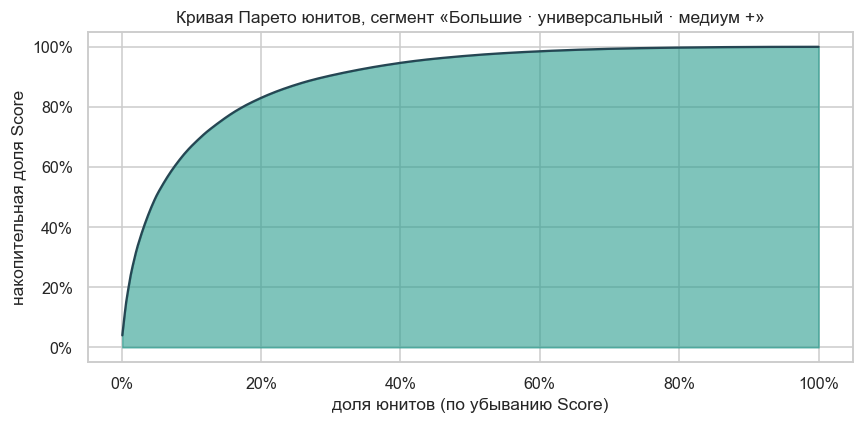

1081 юнитов; половину Score сегмента дают 5% юнитов


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
biggest = n_stores.idxmax()
u = units[units.grp == biggest].reset_index(drop=True)
x = np.arange(1, len(u) + 1) / len(u)
ax.fill_between(x, 0, u.cum_share, color='#2a9d8f', alpha=.6)
ax.plot(x, u.cum_share, color='#264653')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set(title=f'Кривая Парето юнитов, сегмент «{biggest}»', xlabel='доля юнитов (по убыванию Score)',
       ylabel='накопительная доля Score')
plt.tight_layout(); plt.show()
top = (u.cum_share <= 0.5).mean()
print(f'{len(u)} юнитов; половину Score сегмента дают {top:.0%} юнитов')

## Кандидаты на матрицу и выбор

Основной метод - **экспоненциальный порог**: минимум доли товара в Score юнита плавно зависит от веса юнита, а
общая строгость задаётся параметром λ. Кривая строится по 10 значениям λ - от почти всего продаваемого до одних
лидеров, - а выбранная матрица считается точно в точке, где прибыль равна прибыли действующей матрицы.
Защищённые позиции (минимальный ассортимент, собственная марка) входят в матрицу при любом Score.

Каждый вариант сравнивается с действующей матрицей по деньгам **на неделях обучения**. Остатки считаются по
нормативу запаса для каждой пары «точка × товар матрицы»: редкий товар стоит минимум выкладки, ходовой -
страховой запас и половину недельной поставки.

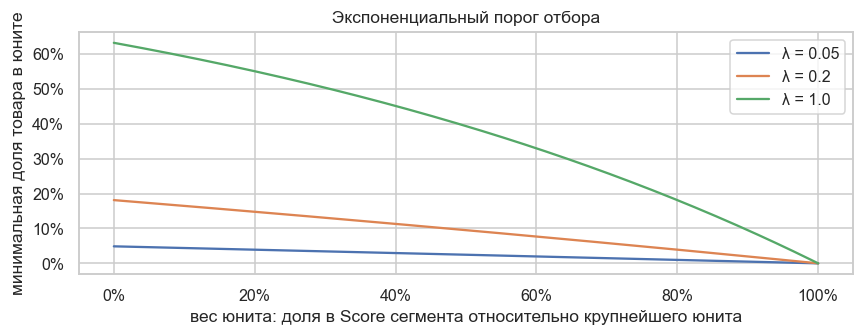

In [10]:
share_grid = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 3.2))
for lam in LAMBDAS_SHOW:
    plt.plot(share_grid, expon.cdf(1 - share_grid, scale=1 / lam), label=f'λ = {lam}')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xlabel('вес юнита: доля в Score сегмента относительно крупнейшего юнита'); plt.ylabel('минимальная доля товара в юните')
plt.title('Экспоненциальный порог отбора'); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
res_train = compare_variants(seg_groups, cand, train)
fact_train = res_train.set_index('вариант').loc['факт']
# правило выбора: минимум остатков при прибыли как у действующей матрицы - точка, где кривая пересекает
# нулевую Δ прибыли на неделях обучения (прибыль - оценка по текущим продажам, остатки сравниваются полностью)
lam_sel, _ = solve_lambda(seg_groups, cand, 'profit', train, fact_train)
selected = f'экспоненциальный (λ={lam_sel:.3g})'
protected = (PROTECT_MIN_ASSORTMENT & cand.is_min_assortment) | (PROTECT_OWN_BRAND & cand.is_own_brand)
cand[selected] = matrix_sign_by_exponential_bound(cand, lam_sel) | (protected & (cand.score > 0))
sel_row = {'вариант': selected, **evaluate(to_pairs(seg_groups, cand, selected), train)}
res_train = pd.concat([res_train, pd.DataFrame([sel_row])], ignore_index=True)
for m in ['stock_rub', 'revenue', 'profit', 'positions']:
    res_train[f'diff_{m}'] = res_train[m] - res_train.loc[0, m]
res_train.style.format({c: '{:,.0f}' for c in res_train.columns if c != 'вариант'})

,вариант,stock_rub,revenue,profit,positions,diff_stock_rub,diff_revenue,diff_profit,diff_positions
0,факт,"665,175,391","523,510,847","133,463,090","1,918",0,0,0,0
1,экспоненциальный (λ=0.01),"889,024,561","609,462,519","154,671,210","2,613","223,849,171","85,951,672","21,208,121",695
2,экспоненциальный (λ=0.018),"874,091,904","608,204,137","154,352,879","2,547","208,916,513","84,693,290","20,889,789",630
3,экспоненциальный (λ=0.032),"846,313,256","605,229,279","153,585,847","2,453","181,137,865","81,718,433","20,122,758",535
4,экспоненциальный (λ=0.058),"807,501,833","599,202,306","152,031,140","2,330","142,326,442","75,691,459","18,568,051",413
5,экспоненциальный (λ=0.11),"752,846,362","586,432,143","148,783,588","2,164","87,670,971","62,921,297","15,320,498",246
6,экспоненциальный (λ=0.19),"699,078,898","570,934,547","145,027,090","2,011","33,903,507","47,423,701","11,564,000",93
7,экспоненциальный (λ=0.34),"648,113,483","550,959,043","139,954,028","1,862","-17,061,908","27,448,196","6,490,939",-56
8,экспоненциальный (λ=0.62),"597,551,440","509,605,568","129,489,864","1,720","-67,623,950","-13,905,279","-3,973,226",-198
9,экспоненциальный (λ=1.1),"551,468,608","450,392,615","114,366,918","1,603","-113,706,782","-73,118,232","-19,096,171",-314


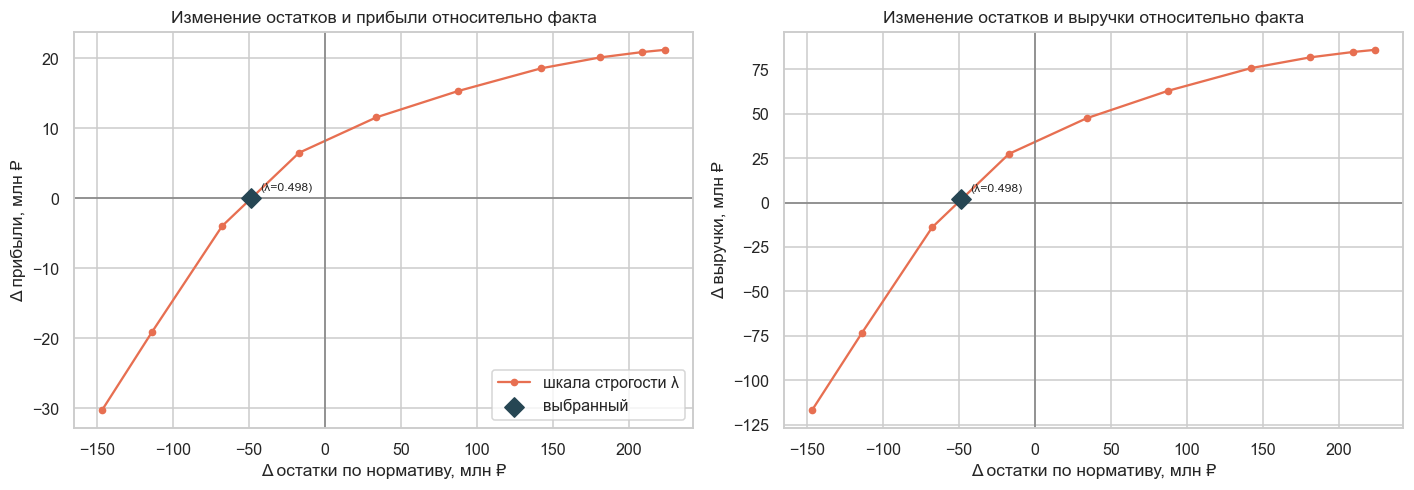

Выбран вариант: экспоненциальный (λ=0.498) (правило: минимум остатков при прибыли как у действующей матрицы, недели обучения)
  остатки -48.9 млн ₽ (-7%), выручка +1.8 млн ₽ (+0.4%), прибыль -0.0 млн ₽ (-0.0%), позиций на точку 1,769 вместо 1,918


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cand_rows = res_train[res_train['вариант'] != 'факт']
for ax, metric, title in [(axes[0], 'diff_profit', 'прибыли'), (axes[1], 'diff_revenue', 'выручки')]:
    e = cand_rows[cand_rows['вариант'] != selected].sort_values('diff_stock_rub')
    ax.plot(e.diff_stock_rub / 1e6, e[metric] / 1e6, color='#e76f51', marker='o', ms=4, label='шкала строгости λ')
    r = cand_rows.set_index('вариант').loc[selected]
    ax.scatter([r.diff_stock_rub / 1e6], [r[metric] / 1e6], s=80, marker='D', color='#264653', zorder=5, label='выбранный')
    ax.annotate(selected.replace('экспоненциальный ', ''), (r.diff_stock_rub / 1e6, r[metric] / 1e6),
                textcoords='offset points', xytext=(6, 5), fontsize=8)
    ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
    ax.set(title=f'Изменение остатков и {title} относительно факта', xlabel='Δ остатки по нормативу, млн ₽', ylabel=f'Δ {title}, млн ₽')
axes[0].legend(loc='lower right'); plt.tight_layout(); plt.show()

best = res_train.set_index('вариант').loc[selected]
print(f'Выбран вариант: {selected} (правило: минимум остатков при прибыли как у действующей матрицы, недели обучения)')
print(f'  остатки {best.diff_stock_rub / 1e6:+.1f} млн ₽ ({best.diff_stock_rub / fact_train.stock_rub:+.0%}), '
      f'выручка {best.diff_revenue / 1e6:+.1f} млн ₽ ({best.diff_revenue / fact_train.revenue:+.1%}), '
      f'прибыль {best.diff_profit / 1e6:+.1f} млн ₽ ({best.diff_profit / fact_train.profit:+.1%}), '
      f'позиций на точку {best.positions:,.0f} вместо {fact_train.positions:,.0f}')

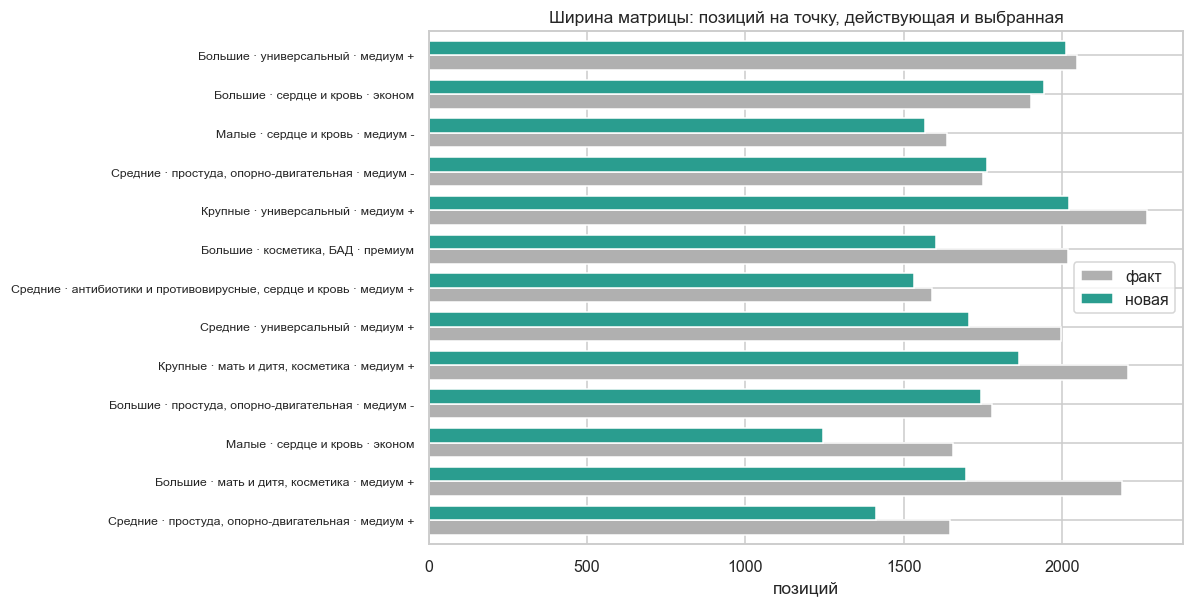

In [13]:
fact_width = fact_pairs.assign(grp=fact_pairs.TradePointId.map(seg_groups)).groupby('grp').size() / n_stores
width = pd.DataFrame({'факт': fact_width, 'новая': cand[cand[selected]].groupby('grp').size()}).loc[n_stores.sort_values().index]
ax = width.plot.barh(figsize=(11, 0.32 * len(width) + 1.5), color=['#b0b0b0', '#2a9d8f'], width=.75)
ax.set(title='Ширина матрицы: позиций на точку, действующая и выбранная', xlabel='позиций', ylabel='')
ax.tick_params(axis='y', labelsize=8); plt.tight_layout(); plt.show()

## Проверка на отложенных неделях

Прибыль в этом расчёте - оценка по текущим продажам: сколько уже наблюдаемого спроса матрица удерживает. Спрос на
товары, которых не было на полке, и переход покупателей на аналоги по данным не видны, поэтому полный эффект на
прибыль покажет только пилот. Остатки же зависят только от состава матрицы и сравниваются между вариантами
полностью. Поэтому главный показатель - **остатки при сопоставимой прибыли**.

Выбор варианта сделан по тем же неделям, по которым считался Score, - такая оценка оптимистична: матрица
подстраивается под случайные всплески продаж. Честная оценка - на неделях, которых расчёт не видел: матрицы
фиксируются, и по реальным продажам второй половины периода считается, сколько они заработали бы.

Заодно сравниваются **способы разбить сеть на группы**. Процедура везде одна (Score, вес юнита, шкала строгости),
меняется только разбиение. Для каждого способа строится кривая «остатки -> прибыль на отложенных неделях» и точно
считаются две точки её пересечения с нулевыми осями:

- **остатки при той же прибыли** - главный разрез: сколько денег в остатках нужно, чтобы удержать прибыль
  действующей матрицы;
- **прибыль при тех же остатках** - второй разрез: сколько прибыли даёт матрица при бюджете остатков действующей.

Способы разбиения:

- **одна матрица на сеть** - нижняя планка: сегментация должна давать больше;
- **категории A-E** - как сейчас в сети: по площади точки;
- **автосегменты** - результат кластеризации;
- **архетипы** - скрытая структура, заложенная в синтетические данные;
- **случайные группы** того же размера, что автосегменты (среднее по нескольким разбиениям) - проверка, что
  выигрыш даёт смысл групп, а не сам факт деления на мелкие группы.

In [14]:
rng = np.random.default_rng(SEED)
groupings = {
    'Одна матрица на сеть': pd.Series('сеть', index=stores.index),
    'Категории A-E': stores.CurrentCategory,
    'Автосегменты': stores.segment,
    'Архетипы': stores.archetype,
}
for i in range(N_RANDOM):
    groupings[f'Случайные группы #{i + 1}'] = pd.Series(rng.permutation(stores.segment.to_numpy()), index=stores.index)

fact_test = evaluate(fact_pairs, test)
rows, curve, cands = [], [], {}
for name, groups in groupings.items():
    c, _ = build_candidates(groups)
    cands[name] = c
    rt = compare_variants(groups, c, train).set_index('вариант')
    # кривая «остатки -> прибыль» по сетке строгости: прибыль и на обучении, и на отложенных неделях
    for vname in EXP_VARIANTS:
        te = evaluate(to_pairs(groups, c, vname), test)
        curve.append({'способ': name, 'вариант': vname, 'lam': dict(VARIANTS)[vname],
                      'Δ остатки': rt.loc[vname].diff_stock_rub, 'Δ прибыль, обучение': rt.loc[vname].diff_profit,
                      'Δ прибыль, проверка': te['profit'] - fact_test['profit']})
    # две точки пересечения с нулевыми осями на отложенных неделях - считаются точно
    lam_s, at_s = solve_lambda(groups, c, 'stock_rub', test, fact_test)
    lam_p, at_p = solve_lambda(groups, c, 'profit', test, fact_test)
    rows.append({'способ': name, 'групп': groups.nunique(),
                 'λ при той же прибыли': lam_p, 'Δ остатки при той же прибыли': at_p['stock_rub'],
                 'позиций при той же прибыли': at_p['positions_abs'],
                 'λ при тех же остатках': lam_s, 'Δ прибыль при тех же остатках': at_s['profit']})
exp = pd.DataFrame(rows)

# случайные разбиения - одной строкой (среднее), разброс - отдельно
rnd = exp[exp['способ'].str.startswith('Случайные')]
rnd_row = rnd.mean(numeric_only=True).to_dict()
rnd_row.update({'способ': 'Случайные группы', 'групп': int(rnd['групп'].iloc[0])})
summary = pd.concat([exp[~exp['способ'].str.startswith('Случайные')], pd.DataFrame([rnd_row])], ignore_index=True)

# кривые: случайные разбиения усредняются по каждому λ
frontier = pd.DataFrame(curve)
is_rnd = frontier['способ'].str.startswith('Случайные')
rnd_curve = frontier[is_rnd].groupby(['вариант', 'lam'], as_index=False)[['Δ остатки', 'Δ прибыль, обучение', 'Δ прибыль, проверка']].mean()
rnd_curve['способ'] = 'Случайные группы'
frontier = pd.concat([frontier[~is_rnd], rnd_curve], ignore_index=True).sort_values(['способ', 'lam'])

# выбранная матрица автосегментов (по неделям обучения) - на отложенных неделях
sel_test = diffs(to_pairs(seg_groups, cand, selected), test, fact_test)
print(f"Выбранная матрица на отложенных неделях: прибыль {sel_test['profit'] / 1e6:+.1f} млн ₽, остатки {sel_test['stock_rub'] / 1e6:+.1f} млн ₽")
print(f"Случайные группы: остатки при той же прибыли от {rnd['Δ остатки при той же прибыли'].min() / 1e6:+.1f} "
      f"до {rnd['Δ остатки при той же прибыли'].max() / 1e6:+.1f} млн ₽")
summary.style.format({c: '{:,.0f}' for c in summary.columns if c not in ('способ', 'вариант')})

Выбранная матрица на отложенных неделях: прибыль -1.6 млн ₽, остатки -48.9 млн ₽
Случайные группы: остатки при той же прибыли от -1.9 до +3.7 млн ₽


,способ,групп,λ при той же прибыли,Δ остатки при той же прибыли,позиций при той же прибыли,λ при тех же остатках,Δ прибыль при тех же остатках
0,Одна матрица на сеть,1,0,"63,109,098","2,078",1,"-15,079,731"
1,Категории A-E,5,0,"26,707,296","1,986",1,"-5,700,885"
2,Автосегменты,13,0,"-43,048,425","1,784",0,"6,961,863"
3,Архетипы,8,0,"-4,848,715","1,893",0,"768,424"
4,Случайные группы,13,0,"1,175,637","1,901",0,"-226,626"


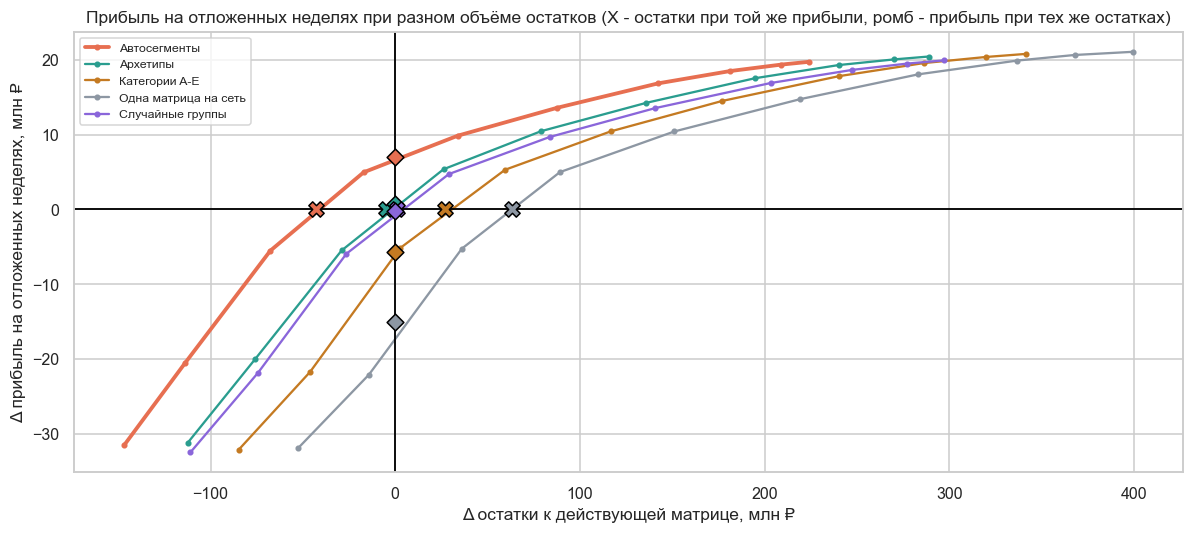

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = {'Одна матрица на сеть': '#8d97a3', 'Категории A-E': '#c47a22', 'Автосегменты': '#e76f51',
           'Архетипы': '#2a9d8f', 'Случайные группы': '#8a66da'}
zero = summary.set_index('способ')
for name, g in frontier.groupby('способ'):
    g = g.sort_values('Δ остатки')
    ax.plot(g['Δ остатки'] / 1e6, g['Δ прибыль, проверка'] / 1e6, marker='o', ms=3, color=palette.get(name), label=name,
            lw=2.5 if name == 'Автосегменты' else 1.5)
    z = zero.loc[name]
    ax.scatter([z['Δ остатки при той же прибыли'] / 1e6], [0], marker='X', s=100, color=palette.get(name), edgecolor='black', zorder=6)
    ax.scatter([0], [z['Δ прибыль при тех же остатках'] / 1e6], marker='D', s=60, color=palette.get(name), edgecolor='black', zorder=6)
ax.axhline(0, color='black', lw=1.2); ax.axvline(0, color='black', lw=1.2)
ax.set(title='Прибыль на отложенных неделях при разном объёме остатков (X - остатки при той же прибыли, ромб - прибыль при тех же остатках)',
       xlabel='Δ остатки к действующей матрице, млн ₽', ylabel='Δ прибыль на отложенных неделях, млн ₽')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

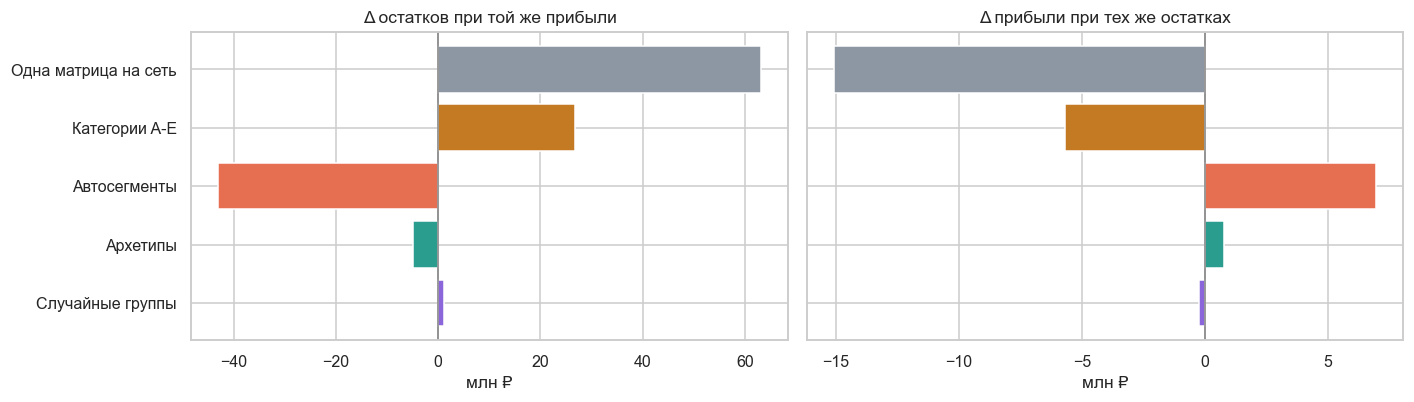

,способ,групп,λ при той же прибыли,Δ остатки при той же прибыли,позиций при той же прибыли,λ при тех же остатках,Δ прибыль при тех же остатках
0,Одна матрица на сеть,1,0.460399,"63,109,098","2,078",0.940231,"-15,079,731"
1,Категории A-E,5,0.470027,"26,707,296","1,986",0.643627,"-5,700,885"
2,Автосегменты,13,0.467601,"-43,048,425","1,784",0.278719,"6,961,863"
3,Архетипы,8,0.480478,"-4,848,715","1,893",0.456840,"768,424"
4,Случайные группы,13,0.457357,"1,175,637","1,901",0.462902,"-226,626"


In [16]:
order = summary.set_index('способ')
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
y = np.arange(len(order))
axes[0].barh(y, order['Δ остатки при той же прибыли'] / 1e6, color=[palette.get(n) for n in order.index])
axes[0].set_yticks(y); axes[0].set_yticklabels(order.index); axes[0].invert_yaxis(); axes[0].axvline(0, color='grey', lw=1)
axes[0].set(title='Δ остатков при той же прибыли', xlabel='млн ₽')
axes[1].barh(y, order['Δ прибыль при тех же остатках'] / 1e6, color=[palette.get(n) for n in order.index])
axes[1].set_yticks(y); axes[1].set_yticklabels([]); axes[1].invert_yaxis(); axes[1].axvline(0, color='grey', lw=1)
axes[1].set(title='Δ прибыли при тех же остатках', xlabel='млн ₽')
plt.tight_layout(); plt.show()
summary.style.format({c: '{:,.0f}' for c in summary.columns if c not in ('способ',) and not c.startswith('λ')})

### По неделям

Как получается результат во времени. Каждый способ выбирает свою матрицу **только по неделям обучения** по тому
же правилу, что и основная: прибыль как у действующей матрицы при минимуме остатков. Дальше матрица не меняется,
и по каждой неделе считаются:

- **прибыль** - по реальным продажам недели, как в общей оценке (товары матрицы + часть продаж исключённых товаров,
  перешедшая на аналоги);
- **остатки** - средний запас по нормативу, пересчитанному по спросу этой недели: так пополняется полка в
  реальной сети.

На неделях обучения прибыль всех способов в сумме равна действующей по построению; на неделях 5-8 видно,
удерживается ли она на новых продажах и сколько денег при этом лежит в запасе.

In [17]:
wk = query(f"""
    SELECT c.TradePointId, c.apCode, date_diff('day', CAST(? AS DATE), CAST(c.Date AS DATE)) // 7 + 1 AS week,
           SUM(c.Amount)                  AS units,
           SUM(c.Sum_Fact)                AS revenue,
           SUM(c.Sum_Fact - c.Sum_Purch)  AS profit
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
      AND c.TradePointId IN (SELECT TradePointId FROM results.store_segments)
    GROUP BY 1, 2, 3
""", [DATE_FROM])
WEEK_DAYS = {w: min(7, (DATA_END - DATE_FROM).days + 1 - 7 * (w - 1)) for w in sorted(wk.week.unique())}
TRAIN_WEEKS = TRAIN_DAYS // 7
WEEKS = [(w, s.reset_index(drop=True)) for w, s in wk.groupby('week')]   # недельные продажи хранятся, чтобы кэш массивов работал


def weekly(pairs: pd.DataFrame) -> pd.DataFrame:
    """Прибыль и остатки матрицы по неделям: прибыль - как в evaluate, остатки - норматив по спросу недели."""
    s_ix, p_ix = pair_codes(pairs)
    key = s_ix.astype(np.int64) * N_PROD + p_ix
    out = []
    for w, s in WEEKS:
        stock = (norm_units(as_sales(s).units_for(key) / WEEK_DAYS[w]) * COST[p_ix]).sum()
        out.append({'week': w, 'profit': evaluate(pairs, s)['profit'], 'stock_rub': stock})
    return pd.DataFrame(out)


week_rows = [weekly(fact_pairs).assign(способ='Действующая матрица', lam=np.nan)]
for name, groups in groupings.items():
    lam_tr, _ = solve_lambda(groups, cands[name], 'profit', train, fact_train)
    week_rows.append(weekly(exp_pairs(groups, cands[name], lam_tr)).assign(способ=name, lam=lam_tr))
by_week = pd.concat(week_rows, ignore_index=True)
is_rnd = by_week['способ'].str.startswith('Случайные')
rnd_week = by_week[is_rnd].groupby('week', as_index=False)[['profit', 'stock_rub', 'lam']].mean().assign(способ='Случайные группы')
by_week = pd.concat([by_week[~is_rnd], rnd_week], ignore_index=True)
by_week.pivot(index='week', columns='способ', values='profit').div(1e6).round(2)

способ,Автосегменты,Архетипы,Действующая матрица,Категории A-E,Одна матрица на сеть,Случайные группы
week,,,,,,
1,33.47,33.49,33.44,33.51,33.49,33.50
2,33.66,33.67,33.72,33.64,33.65,33.63
3,33.45,33.43,33.44,33.41,33.41,33.41
4,32.89,32.88,32.86,32.90,32.91,32.92
5,32.96,33.16,33.38,33.25,33.33,33.00
6,32.78,32.96,33.23,33.05,33.12,32.78
7,32.96,33.18,33.37,33.23,33.30,33.01
8,32.71,32.88,33.00,32.98,33.04,32.72


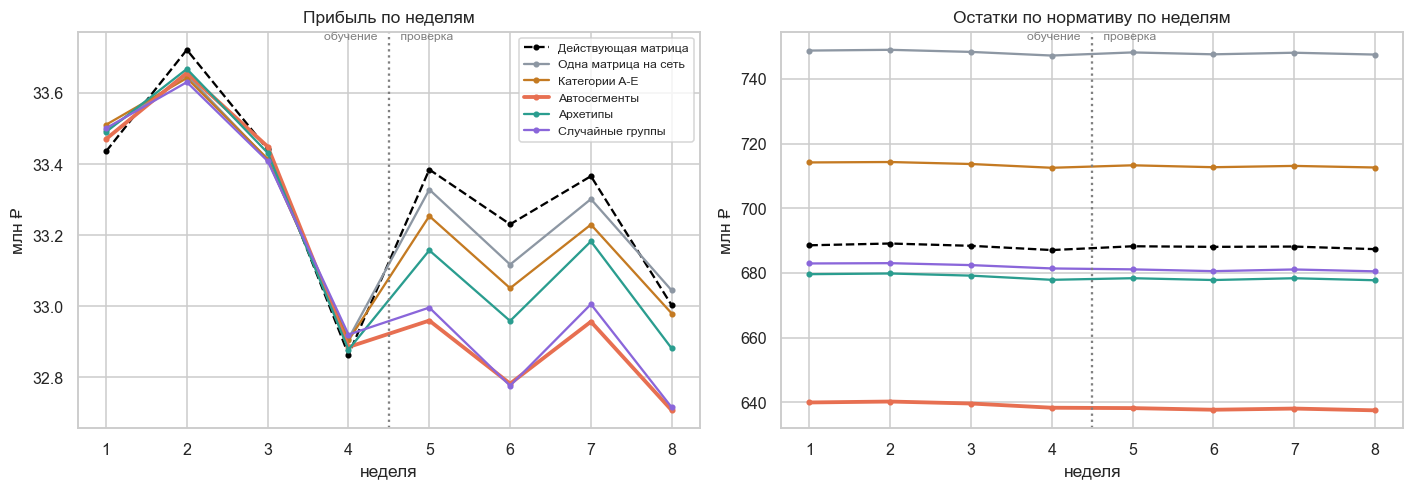

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
pal = {**palette, 'Действующая матрица': 'black'}
for name, g in by_week.groupby('способ', sort=False):
    ls = '--' if name == 'Действующая матрица' else '-'
    lw = 2.5 if name == 'Автосегменты' else 1.5
    axes[0].plot(g.week, g.profit / 1e6, marker='o', ms=3, ls=ls, lw=lw, color=pal.get(name), label=name)
    axes[1].plot(g.week, g.stock_rub / 1e6, marker='o', ms=3, ls=ls, lw=lw, color=pal.get(name), label=name)
for ax, title in [(axes[0], 'Прибыль по неделям'), (axes[1], 'Остатки по нормативу по неделям')]:
    ax.axvline(TRAIN_WEEKS + 0.5, color='grey', ls=':', lw=1.5)
    ax.text(TRAIN_WEEKS + 0.4, 1, 'обучение ', transform=ax.get_xaxis_transform(), ha='right', va='top', color='grey', fontsize=8)
    ax.text(TRAIN_WEEKS + 0.6, 1, ' проверка', transform=ax.get_xaxis_transform(), ha='left', va='top', color='grey', fontsize=8)
    ax.set(title=title, xlabel='неделя', ylabel='млн ₽', xticks=sorted(by_week.week.unique()))
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

### Сохранение результатов

In [19]:
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


final_matrix = cand[cand[selected]].join(products[['name']], on='apCode')[['grp', 'apCode', 'name', 'Unit', 'score', 'score_norm_ap']]
save(final_matrix.rename(columns={'grp': 'segment'}), 'assortment_matrix')

# агрегаты для графиков на сайте
save(units[['grp', 'Unit', 'score_unit', 'share_by_cluster', 'cum_share']].rename(columns={'grp': 'segment'}), 'scoring_units')
variants = res_train.rename(columns={'вариант': 'variant', 'positions': 'positions', 'diff_positions': 'diff_positions'})
variants['selected'] = variants.variant == selected
save(variants, 'scoring_variants')
save(products.reset_index()[['apCode', 'unit_form', 'Unit']], 'product_units')
save(width.reset_index().rename(columns={'index': 'segment', 'grp': 'segment', 'факт': 'fact', 'новая': 'new'})
     .merge(n_stores.rename('n_stores'), left_on='segment', right_index=True), 'scoring_width')
save(summary.rename(columns={'способ': 'method', 'групп': 'groups', 'λ при той же прибыли': 'lam_zero_profit',
                             'Δ остатки при той же прибыли': 'd_stock_zero_profit',
                             'позиций при той же прибыли': 'positions_zero_profit',
                             'λ при тех же остатках': 'lam_zero_stock', 'Δ прибыль при тех же остатках': 'd_profit_zero_stock'}),
     'scoring_experiment')
save(frontier.rename(columns={'способ': 'method', 'вариант': 'variant', 'Δ остатки': 'd_stock',
                              'Δ прибыль, обучение': 'd_profit_train', 'Δ прибыль, проверка': 'd_profit_test'}), 'scoring_frontier')
save(by_week.rename(columns={'способ': 'method'}), 'scoring_weekly')
save(pd.DataFrame([('train_days', TRAIN_DAYS), ('test_days', TEST_DAYS), ('display_units', DISPLAY_UNITS),
                   ('lead_days', LEAD_DAYS), ('review_days', REVIEW_DAYS), ('service_z', SERVICE_Z),
                   ('capital_cost_year', CAPITAL_COST_YEAR), ('n_random', N_RANDOM),
                   ('fact_stock_rub', fact_train.stock_rub), ('fact_profit_train', fact_train.profit),
                   ('fact_revenue_train', fact_train.revenue), ('fact_profit_test', fact_test['profit']),
                   ('fact_positions', fact_train.positions), ('selected_lambda', lam_sel), ('train_weeks', TRAIN_WEEKS),
                   ('selected_profit_test', sel_test['profit']), ('selected_stock_test', sel_test['stock_rub'])],
                  columns=['param', 'value']), 'scoring_params')
con.close()
print(f'results.assortment_matrix: {len(final_matrix):,} строк')

results.assortment_matrix: 22,110 строк


## Отличия от оригинального расчёта

- **Score - выручка товара на точку сегмента**, без поправки на ценовой уровень: в оригинале Score брался из
  отдельного расчёта, а бонусы и штрафы за цену задавались экспертными коэффициентами.
- **Без ABC-классов юнитов**: в оригинале у каждого класса был свой порог отбора, здесь важность юнита
  учитывается плавно, через его вес в сегменте, а общая строгость задаётся одним параметром λ.
- **Юниты** построены из справочника: МНН + форма с путём введения + дозировка + категория фасовки (пачка на 10
  и на 100 таблеток - разные юниты); в оригинале - готовый справочник юнитов.
- **Остатки считаются по нормативу запаса** для каждой пары «точка × товар», а не по фактическому остатку:
  так видно, сколько денег замораживает каждый вариант матрицы.
- **Деньги считаются по точкам**: у каждой точки своя матрица (её сегмента) и свои продажи.
- **Защищённые позиции** (минимальный ассортимент, СТМ) включены как переключаемая опция.
- **Переключение спроса**: при исключении товара половина его продаж переходит на аналоги из того же юнита.
- **Выбор варианта формализован**: минимум остатков при прибыли как у действующей матрицы, строгость подбирается
  точно, а не выбирается вручную из нескольких вариантов по графику.
- **Добавлена проверка на отложенных неделях** и сравнение способов сегментации - в оригинале такой проверки не было.